Muchas veces nos enfrentamos a problemas de clasificación en los que los datos están desbalanceados. Este es un inconveniente muy común, y existen diversas técnicas para abordarlo, como el submuestreo o el sobremuestreo. En este caso, aplicaremos sobremuestreo a la clase desbalanceada utilizando redes GAN.

In [4]:
import pandas as pd
import numpy as np
from statsmodels.stats.stattools import medcouple
from pathlib import Path
import os

Antes de aplicar las redes GAN, es necesario contar con datos limpios. Por ello, hemos creado la clase ColvaltoCsvDataCleaner, la cual se encarga de eliminar datos atípicos y procesar algunas variables categóricas.

In [5]:
class CovaltoCsvDataCleaner:
    """
    Clase encargada de limpiar los datos provenientes de un archivo csv de la 
    base de datos de covalto.

    Attributes
    ----------
    file_path: str or Path
        Ruta del archivo csv a limpiar
    """

    def __init__(self,file_path):

        """
        función que inicializa la clase con la ruta del archivo y verifica que
        el archivo exista.
        
        Attributes
        ----------
        file_path: Ruta del archivo csv a limpiar

        Raises
        ------
        FileNotFoundError
            Si el archivo específicado no existe

        """

        self.file_path = Path(file_path)
        if not self.file_path.exists():
            raise FileNotFoundError(f"El archivo no existe: {self.file_path}")
        
        self.data = None                    
        

    
    def load_dataset(self):

        """
        Lee el archivo csv indicado en el self.file_path y lo carga como un
        dataframe de pandas.

        return
        ------
        pd.DataFrame
            DataFrame que contiene los datos leidos del archivo csv.

        Raises
        ------
        pandas.errors.EmptyDataError
            Si el archivo está vacío

        pandas.errors.ParserError
            Si el archivo CSV tiene errores de formato o no puede ser parseado correctamente.
        """

        self.data = pd.read_csv(self.file_path)
        return self.data
    
    
    def remove_outliers(self, col_interes='ingresos_anuales_mxn',max_retries=3):

        """
        Elimina los valores atípicos de una columna numérica usando el estadístico MedCouple (MC).

        Este método ajusta los límites inferior y superior de detección de outliers 
        en función de la asimetría de la distribución, medida con el estadístico MedCouple.

        Parameters
        ----------
        covalto_dataset_raw: pd.DataFrame
            DataFrame que contiene los datos a procesar.

        col_interes: str 
            Nombre de la columna sobre la cual se eliminaran los valores atípicos.
            Por defecto es 'ingresos_anuales_mxn'.

        max_retries : int
            Número máximo de intentos para ingresar una columna válida.
            Por defecto es 3.
        
        Return
        ------
        pandas.DataFrame
            Copia del DataFrame original sin los valores atípicos en la columna indicada.

        Raises
        ------
        ValueError
            Si no se proporciona una columna válida después de varios intentos.
        
        Notes
        -----
            - Si el MedCouple (MC) es positivo, se ajusta más el límite inferior.
            - Si el MC es negativo, se ajusta más el límite superior.
            - Si el MC es 0, se aplica la regla estándar del rango intercuartílico (IQR).

        """

        if self.data is None:
            raise ValueError("El dataset no ha sido cargado. Ejecute load_dataset() primero.")
        
        attempt = 0
        while attempt<max_retries:
            try:
                # Intenta acceder a la columna
                data = self.data.copy()
                _=data[col_interes]

                # Calcular estadísticas
                resumen = data[col_interes].describe()
                Q1, Q2, Q3 = resumen.iloc[4], resumen.iloc[5], resumen.iloc[6]
                RI = Q3 - Q1
                MC = medcouple(data[col_interes].to_numpy())

                # Determinar límites
                if MC > 0:
                    lim_inf_MC = Q1 - 1.5 * np.exp(-3.5 * MC) * RI
                    lim_sup_MC = Q3 + 1.5 * np.exp(4 * MC) * RI
                elif MC < 0:
                    lim_inf_MC = Q1 - 1.5 * np.exp(-4 * MC) * RI
                    lim_sup_MC = Q3 + 1.5 * np.exp(3.5 * MC) * RI
                else:
                    lim_inf_MC = Q1 - 1.5 * RI
                    lim_sup_MC = Q3 + 1.5 * RI

                data = data[
                    (data[col_interes] >= lim_inf_MC) &
                    (data[col_interes] <= lim_sup_MC) |
                    (data[col_interes].isna())
                ]
                self.data = data.copy()
                return self.data
            
            except KeyError:
                print(f"La columna '{col_interes}' no existe en el DataFrame.")
                attempt += 1
                if attempt < max_retries:
                    col_interes = input("Por favor, ingrese el nombre correcto de la columna: ")
                else:
                    raise ValueError("No se proporcionó una columna válida después de varios intentos.")

    def standardize_sector_column(self,col_name='sector_industrial',max_retries=3):
        """
        Estandariza los nombres del sector industrial en el DataFrame.
        
        Reemplaza valores inconsistentes o en minúsculas por versiones normalizadas.

        Parameters
        ----------
        data : pandas.DataFrame
            DataFrame a procesar.
        
        col_name: str
            Nobre de la columna sobre la cual se estarizarán las categorías
        
        max_retries: int
            Número máximo de intentos para ingregar una columna válida
            Por defecto es 3.
        Returns
        -------
        pandas.DataFrame
            Copia del DataFrame con los nombres del sector estandarizados.
        """
        
        attempt = 0
        while attempt<max_retries:
            try:
                self.data[col_name] = self.data[col_name].replace({
                 'retail': 'Retail'   
                })
                return self.data
            except KeyError:
                print(f"la columna {col_name} no existe en el DataFrame.")
                attempt +=1
                if attempt<max_retries:
                    col_name = input('Ingrese el nombre correcto de la columna: ')
                else:
                    ValueError("No se proporcionó una columna válida después de varios intentos")

Limpiemos los datos y veamos que es lo que tenemos

In [6]:
file_path = lambda file : os.path.join(os.getcwd(),'data',file)

In [7]:
# 2. Carga los datos
cleaner = CovaltoCsvDataCleaner(file_path('covalto_sme_credit_data.csv'))   # Crear instancia
data = cleaner.load_dataset()    

# 3. Limpia Outliers
data = cleaner.remove_outliers(
    col_interes ='ingresos_anuales_mxn',
    max_retries=3
)

# 4. Reemplaza retail por Retail en la columna 'sector_industrial'
data = cleaner.standardize_sector_column(
    col_name = 'sector_industrial',
    max_retries = 3)
data.head()

,id_cliente,antiguedad_empresa_anos,sector_industrial,ingresos_anuales_mxn,deuda_total_mxn,historial_pagos_atrasados,calificacion_buro,default_12m,monto_solicitado_mxn
0,COV-1000,9.5,Manufactura,5388966.19,4093290.34,1,D,0,1042088.49
1,COV-1001,6.9,Construcción,806689.27,184032.16,3,C,0,658716.30
2,COV-1002,10.2,Servicios Profesionales,4721557.55,2875892.65,1,B,0,656435.67
3,COV-1003,15.8,Retail,400301.58,284881.54,1,B,0,289018.04
4,COV-1004,6.6,Retail,6110431.90,5935242.68,2,NaN,0,694186.35


Veamos ahora como estamos de valores faltantes

In [8]:
data.isnull().sum()

id_cliente                     0
antiguedad_empresa_anos       75
sector_industrial              0
ingresos_anuales_mxn          45
deuda_total_mxn                0
historial_pagos_atrasados      0
calificacion_buro            119
default_12m                    0
monto_solicitado_mxn           0
dtype: int64

Podemos ver que tenemos datos faltantes en la columna de calificación buro, veamos como los podemos reemplazar.

In [9]:
data['calificacion_buro'].value_counts()

calificacion_buro
B    510
A    444
C    276
D    143
Name: count, dtype: int64

Es una variable categórica ordinal, por lo tanto, los valores faltantes en esta columna pueden asignarse con un valor de cero.

In [10]:
data['calificacion_buro'] = data['calificacion_buro'].map({
    np.nan:0,
    'A':1,
    'B':2,
    'C':3,
    'D':4
    })

In [11]:
data.isnull().sum()

id_cliente                    0
antiguedad_empresa_anos      75
sector_industrial             0
ingresos_anuales_mxn         45
deuda_total_mxn               0
historial_pagos_atrasados     0
calificacion_buro             0
default_12m                   0
monto_solicitado_mxn          0
dtype: int64

Los demás valores faltantes se eliminarán (con fines demostrativos), ya que las redes GAN requieren datos completos para su entrenamiento.

In [12]:
data = data.dropna()
data.head()

,id_cliente,antiguedad_empresa_anos,sector_industrial,ingresos_anuales_mxn,deuda_total_mxn,historial_pagos_atrasados,calificacion_buro,default_12m,monto_solicitado_mxn
0,COV-1000,9.5,Manufactura,5388966.19,4093290.34,1,4,0,1042088.49
1,COV-1001,6.9,Construcción,806689.27,184032.16,3,3,0,658716.30
2,COV-1002,10.2,Servicios Profesionales,4721557.55,2875892.65,1,2,0,656435.67
3,COV-1003,15.8,Retail,400301.58,284881.54,1,2,0,289018.04
4,COV-1004,6.6,Retail,6110431.90,5935242.68,2,0,0,694186.35


Ahora si, veamos como están las clases balancedas.

In [13]:
data['default_12m'].value_counts(normalize=True)

default_12m
0    0.880727
1    0.119273
Name: proportion, dtype: float64

Perfecto, ahora seleccionemos las características que son importantes.

In [14]:
data = data[['historial_pagos_atrasados', 
             'calificacion_buro', 
             'monto_solicitado_mxn', 
             'default_12m']]
data.head()

,historial_pagos_atrasados,calificacion_buro,monto_solicitado_mxn,default_12m
0,1,4,1042088.49,0
1,3,3,658716.30,0
2,1,2,656435.67,0
3,1,2,289018.04,0
4,2,0,694186.35,0


Ahora, escalemos los datos en un rango de 0 a 1.

In [15]:
from sklearn import preprocessing
def escalar_datos(no_escalar,df):
    X = df.drop(columns=no_escalar,axis=1)
    y = df[no_escalar]
    escalador = preprocessing.MinMaxScaler(feature_range=(-1, 1))
    X_nor = pd.DataFrame(escalador.fit_transform(X),
                         columns = X.columns,
                         index=X.index)
    dfnor = pd.concat([y,X_nor],axis=1)
    return dfnor,escalador


# GAN

Las redes generativas de confrontación (GAN) representan un enfoque  avanzado para generar datos sintéticos. Una GAN consiste en dos redes neuronales que compiten entre sí: un generador que crea nuevos datos y un discriminador que intenta distinguir los datos reales de los datos generados. A medida que avanza el entrenamiento, el generador mejora para producir datos cada vez más realistas, mientras que el discriminador refina su capacidad para detectar falsificaciones.

In [20]:
from ctgan import CTGAN
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Entrenar CTGAN solo con la clase minoritaria (default = 1)
ctgan = CTGAN(
    epochs=1000,  # Más épocas para mejor calidad
    batch_size=10,
    generator_dim=(256, 256, 256),
    discriminator_dim=(256, 256, 256),
    verbose=True,
    pac=10  # Mayor regularización
)

In [21]:
df_default_1 = data[data['default_12m']==1]

print("\nEntrenando CTGAN con la clase minoritaria...")
ctgan.fit(df_default_1, ['default_12m'])  # 'default_12m' es la columna discreta


Entrenando CTGAN con la clase minoritaria...


Gen. (-0.46) | Discrim. (0.14): 100%|██████████| 1000/1000 [03:29<00:00,  4.77it/s]


In [22]:
# 5. Generar datos sintéticos para balancear
df_default_0 = data[data['default_12m']==0]
num_samples_to_generate = len(df_default_0) - len(df_default_1)
print(f"\nGenerando {num_samples_to_generate} muestras sintéticas...")
synthetic_data = ctgan.sample(num_samples_to_generate)


Generando 1047 muestras sintéticas...


In [23]:
def comparar_distribuciones(original, sintetico, variable):
    plt.figure(figsize=(8, 5))
    sns.kdeplot(original[variable], color='blue', label='Original', fill=True, alpha=0.3)
    sns.kdeplot(sintetico[variable], color='red', label='Sintético', fill=True, alpha=0.3)
    plt.title(f'Distribución comparada - {variable}')
    plt.xlabel(variable)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Comparando distribuciones...


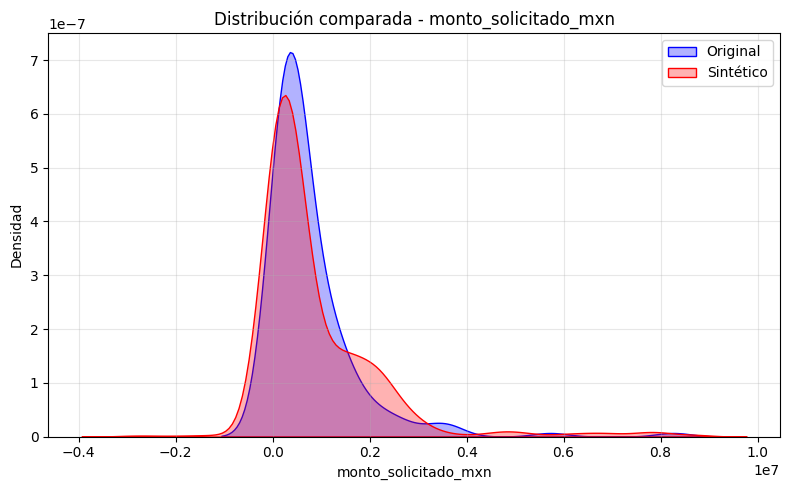

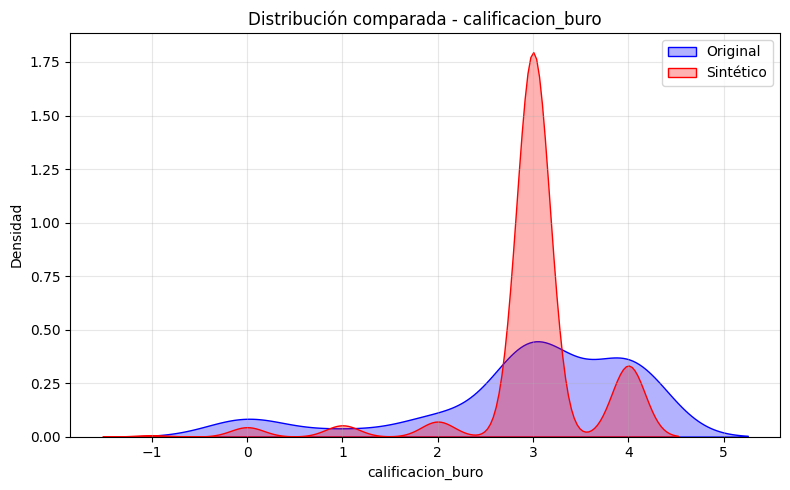

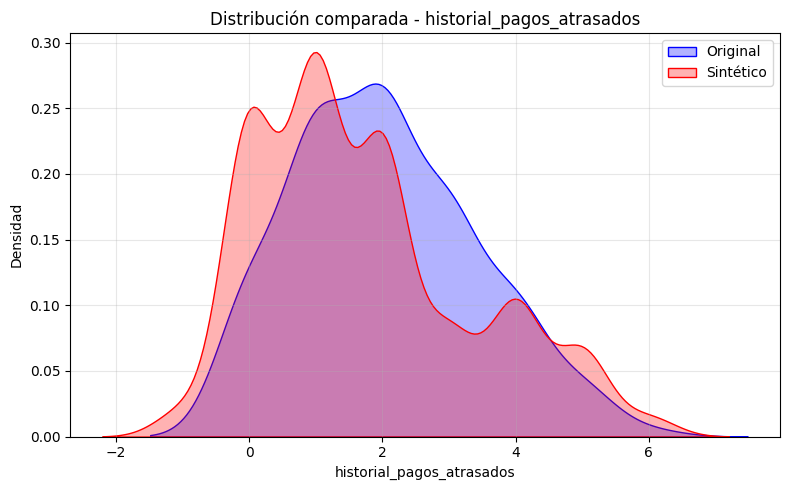

In [24]:
# Comparar variables clave
print("\nComparando distribuciones...")
comparar_distribuciones(df_default_1, synthetic_data, 'monto_solicitado_mxn')
comparar_distribuciones(df_default_1, synthetic_data, 'calificacion_buro')
comparar_distribuciones(df_default_1, synthetic_data, 'historial_pagos_atrasados')

Obtimizando con optuna

In [23]:
import optuna
from ctgan import CTGAN
from sdv.evaluation.single_table import evaluate_quality
from sdv.metadata import SingleTableMetadata

df_default_1 = data[data['default_12m']==1]


def objective(trial):
    # 1️⃣ Definir hiperparámetros válidos
    generator_dim = tuple([trial.suggest_int(f"gen_units_{i}", 64, 512) for i in range(3)])
    discriminator_dim = tuple([trial.suggest_int(f"disc_units_{i}", 64, 512) for i in range(3)])
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 40])
    pac = trial.suggest_categorical("pac", [1, 2, 4, 8])
    epochs = trial.suggest_int("epochs", 100, 400)

    # 🚨 Saltar combinaciones incompatibles
    if batch_size % pac != 0:
        raise optuna.exceptions.TrialPruned()

    # 2️⃣ Entrenar modelo
    model = CTGAN(
        epochs=epochs,
        batch_size=batch_size,
        generator_dim=generator_dim,
        discriminator_dim=discriminator_dim,
        pac=pac,
        verbose=False
    )
    model.fit(df_default_1)

    # 3️⃣ Generar datos sintéticos
    synthetic = model.sample(len(df_default_1))

    # 4️⃣ Crear metadatos
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df_default_1)

    # 5️⃣ Evaluar calidad
    quality = evaluate_quality(
        real_data=df_default_1,
        synthetic_data=synthetic,
        metadata=metadata,
        verbose=False
    )

    # 6️⃣ Extraer score global (nuevo formato)
    score = quality.get_score()

    # 7️⃣ Optuna minimiza → devolver negativo
    return -score


In [24]:
study = optuna.create_study(direction="minimize")  # porque devolvemos -score
study.optimize(objective, n_trials=30)

print("Mejores hiperparámetros:", study.best_trial.params)
print("Mejor puntaje (calidad sintética):", -study.best_value)

[I 2025-10-30 10:55:24,528] A new study created in memory with name: no-name-9fe16ce8-5aee-4287-be64-fe08f0569c60
[I 2025-10-30 10:55:39,087] Trial 0 finished with value: -0.5505589443070841 and parameters: {'gen_units_0': 451, 'gen_units_1': 290, 'gen_units_2': 256, 'disc_units_0': 74, 'disc_units_1': 109, 'disc_units_2': 219, 'batch_size': 16, 'pac': 1, 'epochs': 114}. Best is trial 0 with value: -0.5505589443070841.
[I 2025-10-30 10:55:48,138] Trial 1 finished with value: -0.6283028469645424 and parameters: {'gen_units_0': 343, 'gen_units_1': 206, 'gen_units_2': 217, 'disc_units_0': 384, 'disc_units_1': 451, 'disc_units_2': 313, 'batch_size': 32, 'pac': 4, 'epochs': 144}. Best is trial 1 with value: -0.6283028469645424.
[I 2025-10-30 10:55:56,842] Trial 2 finished with value: -0.6974085378913222 and parameters: {'gen_units_0': 356, 'gen_units_1': 180, 'gen_units_2': 292, 'disc_units_0': 334, 'disc_units_1': 241, 'disc_units_2': 431, 'batch_size': 40, 'pac': 2, 'epochs': 173}. Best i

Mejores hiperparámetros: {'gen_units_0': 212, 'gen_units_1': 70, 'gen_units_2': 81, 'disc_units_0': 500, 'disc_units_1': 496, 'disc_units_2': 66, 'batch_size': 8, 'pac': 8, 'epochs': 246}
Mejor puntaje (calidad sintética): 0.8460365876384964


Perfecto, entrenemos la red con los mejores hiperparámetros encontrados

In [49]:
best_params = {
    'generator_dim': (212, 70, 81),
    'discriminator_dim': (500, 496, 66), 
    'batch_size': 8,
    'pac': 8,
    'epochs': 1000
}

model = CTGAN(**best_params, verbose=True)
model.fit(df_default_1)
synthetic_data = model.sample(len(df_default_1))  

Gen. (-0.39) | Discrim. (-1.49): 100%|██████████| 1000/1000 [04:09<00:00,  4.01it/s]


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
def comparar_distribuciones(original, sintetico, variable):
    plt.figure(figsize=(8, 5))
    sns.kdeplot(original[variable], color='blue', label='Original', fill=True, alpha=0.3)
    sns.kdeplot(sintetico[variable], color='red', label='Sintético', fill=True, alpha=0.3)
    plt.title(f'Distribución comparada - {variable}')
    plt.xlabel(variable)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Comparando distribuciones...


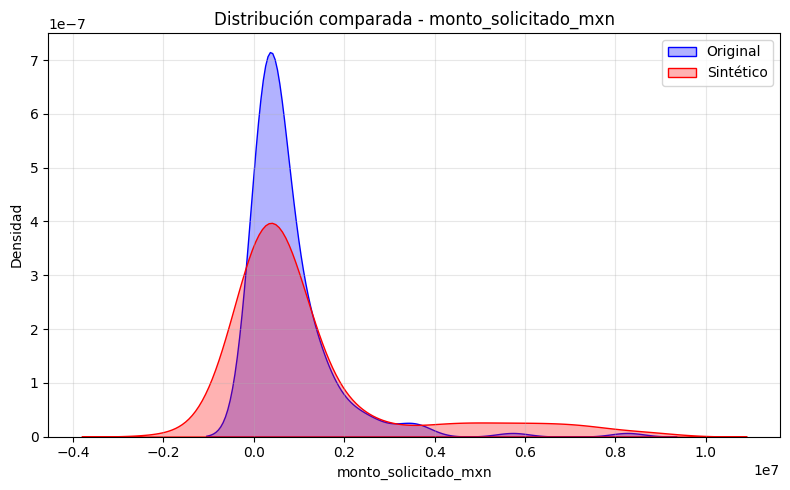

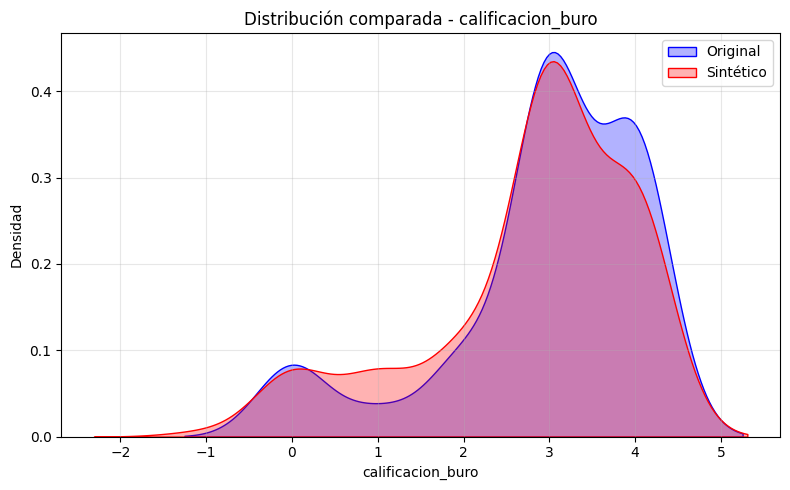

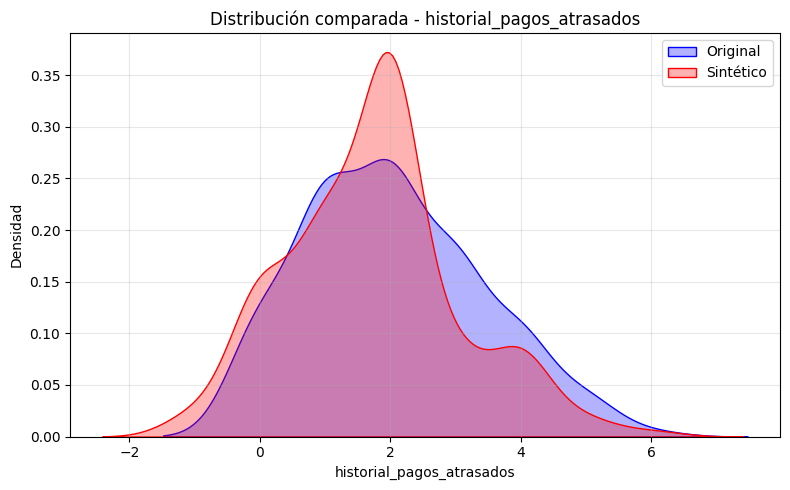

In [29]:
# Comparar variables clave
print("\nComparando distribuciones...")
comparar_distribuciones(df_default_1, synthetic_data, 'monto_solicitado_mxn')
comparar_distribuciones(df_default_1, synthetic_data, 'calificacion_buro')
comparar_distribuciones(df_default_1, synthetic_data, 'historial_pagos_atrasados')